In [1]:
# Install library yang dibutuhkan
!pip install -q -U diffusers transformers accelerate peft bitsandbytes
!pip install -q datasets scipy
!pip install -q kaggle

print("Instalasi selesai. Silakan lanjut ke langkah berikutnya.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 19.0 MB/s eta 0:00:00
Instalasi selesai. Silakan lanjut ke langkah berikutnya.


In [5]:
import os

# Konfigurasi Kaggle (HARUS folder)
os.environ['KAGGLE_CONFIG_DIR'] = "/content/drive/MyDrive/BUDAYA GO/Code"

# Cek apakah kaggle.json ada
!ls "/content/drive/MyDrive/BUDAYA GO/Code"

# Download dataset
!kaggle datasets download -d dionisiusdh/indonesian-batik-motifs

# Ekstrak
!unzip -q indonesian-batik-motifs.zip -d batik_dataset

# Cek folder
print("Folder dataset berhasil diekstrak:")
!ls batik_dataset

kaggle.json  RupaGen.ipynb
Dataset URL: https://www.kaggle.com/datasets/dionisiusdh/indonesian-batik-motifs
License(s): CC0-1.0
 93% 243M/262M [00:00<00:00, 743MB/s] 
100% 262M/262M [00:00<00:00, 366MB/s]
Folder dataset berhasil diekstrak:
batik-bali	   batik-ciamis     batik-lasem        batik-sekar
batik-betawi	   batik-garutan    batik-megamendung  batik-sidoluhur
batik-celup	   batik-gentongan  batik-parang       batik-sidomukti
batik-cendrawasih  batik-kawung     batik-pekalongan   batik-sogan
batik-ceplok	   batik-keraton    batik-priangan     batik-tambal


In [6]:
import csv
import os
from PIL import Image

# Lokasi dataset yang sudah diunzip
dataset_root = "/content/batik_dataset"
output_csv = "/content/batik_dataset/metadata.csv"

# List untuk CSV
data_rows = []

IMAGES_PER_STYLE = 20  # Batas 20 gambar per motif

for folder_name in os.listdir(dataset_root):
    folder_path = os.path.join(dataset_root, folder_name)

    if os.path.isdir(folder_path):
        # Membersihkan nama style
        style_name = folder_name.replace("batik-", "").replace("-", " ")

        # Ambil gambar
        images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        # Pilih sebagian gambar
        selected_images = images[:IMAGES_PER_STYLE]

        # Masukkan semua ke CSV
        for img_file in selected_images:
            prompt = f"batik pattern, {style_name} style, traditional indonesian art"
            image_path = f"{folder_name}/{img_file}"
            data_rows.append([image_path, prompt])

# Tulis ke CSV
with open(output_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["file_name", "text"])
    writer.writerows(data_rows)

print(f"Metadata berhasil dibuat! Total gambar untuk training: {len(data_rows)}")
print(f"Contoh Prompt: {data_rows[0][1]}")

Metadata berhasil dibuat! Total gambar untuk training: 400
Contoh Prompt: batik pattern, sidomukti style, traditional indonesian art


In [8]:
!wget -O train_text_to_image_lora.py https://raw.githubusercontent.com/huggingface/diffusers/main/examples/text_to_image/train_text_to_image_lora.py

--2025-11-22 07:14:11--  https://raw.githubusercontent.com/huggingface/diffusers/main/examples/text_to_image/train_text_to_image_lora.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 41276 (40K) [text/plain]
Saving to: ‘train_text_to_image_lora.py’

train_text_to_image 100%[===================>]  40.31K  --.-KB/s    in 0.002s  

2025-11-22 07:14:11 (20.1 MB/s) - ‘train_text_to_image_lora.py’ saved [41276/41276]



In [10]:
!pip uninstall -y diffusers
!pip install git+https://github.com/huggingface/diffusers
!pip install accelerate transformers safetensors

Found existing installation: diffusers 0.35.2
Uninstalling diffusers-0.35.2:
  Successfully uninstalled diffusers-0.35.2
  Cloning https://github.com/huggingface/diffusers to /tmp/pip-req-build-13ypxiy1
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers /tmp/pip-req-build-13ypxiy1
  Resolved https://github.com/huggingface/diffusers to commit 6f1042e36cd588a7b66498f45c3bb7085e4fa395
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.36.0.dev0-py3-none-any.whl size=4475017 sha256=2c4f67be33e947f4de59cbd24ebe03ca548c1f121d2d92d6472c2cbbefb4a064
  Stored in directory: /tmp/pip-ephem-wheel-cache-n_dxbtze/wheels/90/d4/44/a58bc00fb405fefb633b0d9d2307f6e3aec6cc1775d82555d3
Successfully built diffusers


In [15]:
import os
from PIL import Image

root = "/content/batik_dataset"
bad_files = []

for folder, _, files in os.walk(root):
    for file in files:
        path = os.path.join(folder, file)
        try:
            img = Image.open(path)
            img.verify()
        except:
            print("BAD FILE:", path)
            bad_files.append(path)

print("\nTotal bad files:", len(bad_files))

BAD FILE: /content/batik_dataset/metadata.csv
BAD FILE: /content/batik_dataset/batik-cendrawasih/18.jpg
BAD FILE: /content/batik_dataset/batik-megamendung/49.jpg

Total bad files: 3


In [16]:
for f in bad_files:
    os.remove(f)
    print("Removed:", f)

Removed: /content/batik_dataset/metadata.csv
Removed: /content/batik_dataset/batik-cendrawasih/18.jpg
Removed: /content/batik_dataset/batik-megamendung/49.jpg


In [17]:
import cv2

root = "/content/batik_dataset"
bad_cv = []

for folder, _, files in os.walk(root):
    for file in files:
        path = os.path.join(folder, file)
        try:
            img = cv2.imread(path)
            if img is None:
                bad_cv.append(path)
        except:
            bad_cv.append(path)

print("OpenCV bad files:", bad_cv)

OpenCV bad files: []


In [20]:
import os
from PIL import Image
import pandas as pd

dataset_dir = "/content/batik_dataset"
data = []

for folder in os.listdir(dataset_dir):
    folder_path = os.path.join(dataset_dir, folder)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        if file.lower().endswith((".jpg", ".png", ".jpeg")):
            img_path = os.path.join(folder_path, file)

            caption = f"batik motif {folder.replace('-', ' ')}"
            data.append([img_path, caption])

df = pd.DataFrame(data, columns=["image", "text"])
df.to_csv("/content/batik_dataset/captions.csv", index=False)

df.head()

,image,text
0,/content/batik_dataset/batik-sidomukti/21.jpg,batik motif batik sidomukti
1,/content/batik_dataset/batik-sidomukti/11.jpg,batik motif batik sidomukti
2,/content/batik_dataset/batik-sidomukti/19.jpg,batik motif batik sidomukti
3,/content/batik_dataset/batik-sidomukti/38.jpg,batik motif batik sidomukti
4,/content/batik_dataset/batik-sidomukti/16.jpg,batik motif batik sidomukti


In [22]:
import os
import json
from PIL import Image

root = "/content/batik_dataset"
save_dir = "/content/batik_dataset_ready"

os.makedirs(save_dir + "/image", exist_ok=True)

metadata = []

idx = 0
for folder in os.listdir(root):
    folder_path = os.path.join(root, folder)

    if not os.path.isdir(folder_path):
        continue

    # caption dari nama folder
    caption = f"batik motif {folder.replace('-', ' ')}"

    for file in os.listdir(folder_path):
        if file.lower().endswith((".jpg", ".png", ".jpeg")):

            old_path = os.path.join(folder_path, file)
            new_path = f"{save_dir}/image/{idx}.jpg"

            # copy image
            Image.open(old_path).convert("RGB").save(new_path)

            metadata.append({
                "file_name": f"image/{idx}.jpg",
                "text": caption
            })

            idx += 1

# simpan metadata.jsonl
with open(f"{save_dir}/metadata.jsonl", "w") as f:
    for m in metadata:
        f.write(json.dumps(m) + "\n")

len(metadata)

981

In [24]:
!accelerate launch --mixed_precision="bf16" \
  /content/train_text_to_image_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --train_data_dir="/content/batik_dataset_ready" \
  --caption_column="text" \
  --image_column="image" \
  --resolution=512 --random_flip \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --gradient_checkpointing \
  --max_train_steps=1000 \
  --learning_rate=1e-04 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --output_dir="/content/rupagen-batik-model" \
  --seed=42

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
2025-11-22 07:49:06.131735: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763797746.164962   13198 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763797746.174997   13198 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763797746.200215   13198 computation_placer.cc:177] computation placer already registered. 

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

safety_checker/model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


Sedang membuat motif...


  0%|          | 0/30 [00:00<?, ?it/s]

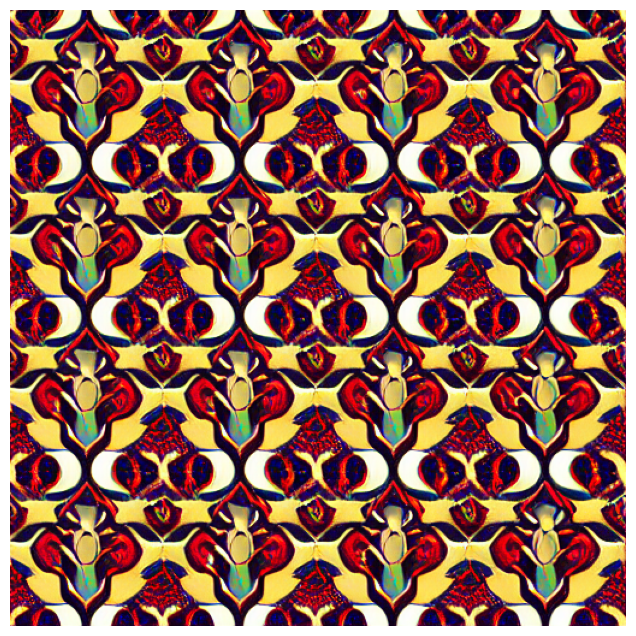

In [25]:
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt

# 1. Load Model Dasar
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)

# 2. Load Hasil Training Kita (LoRA)
# Ini adalah "jiwa" dataset batik Anda yang disuntikkan ke model
pipe.load_lora_weights("/content/rupagen-batik-model", weight_name="pytorch_lora_weights.safetensors")

# Pindahkan ke GPU
pipe.to("cuda")

# 3. Tentukan Prompt (Perintah Teks)
# Gunakan format prompt yang mirip saat training: "batik pattern, [nama_style] style"
# Kita coba gabungkan dengan konsep modern (neon, cyberpunk, dll)
prompt = "batik pattern, parang style, red and gold color, high quality, detailed, 4k"
negative_prompt = "blurry, ugly, low quality, distortion, watermarked"

# 4. Generate!
print("Sedang membuat motif...")
image = pipe(prompt, negative_prompt=negative_prompt, num_inference_steps=30, guidance_scale=7.5).images[0]

# 5. Tampilkan Hasil
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

# Simpan gambar jika bagus
image.save("hasil_rupagen_parang.png")

In [33]:
import shutil
from google.colab import files

# Path folder yang ingin di-zip
folder_path = "/content/rupagen-batik-model"

# Nama file zip yang akan dibuat
zip_path = "/content/rupagen-batik-model.zip"

# Membuat file ZIP
shutil.make_archive("/content/rupagen-batik-model", 'zip', folder_path)

# Download ZIP ke komputer lokal
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
import shutil
from google.colab import files

# Path folder yang ingin di-zip
folder_path = "/content/batik_dataset_ready"

# Nama file zip yang akan dibuat
zip_path = "/content/batik_dataset_ready.zip"

# Membuat file ZIP
shutil.make_archive("/content/batik_dataset_ready", 'zip', folder_path)

# Download ZIP ke komputer lokal
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
import shutil
from google.colab import files

# Path folder yang ingin di-zip
folder_path = "/content/batik_dataset"

# Nama file zip yang akan dibuat
zip_path = "/content/batik_dataset.zip"

# Membuat file ZIP
shutil.make_archive("/content/batik_dataset", 'zip', folder_path)

# Download ZIP ke komputer lokal
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>